# Educational QNLP   
## Manual SVO Annotation → Grammar-Controlled Quantum Circuit → Parameter-Shift Training → Simulator → Optional IBM Hardware

This notebook  demonstrates the core QNLP idea in a controlled way:

1. Sentences are represented as manually annotated SVO records.
2. Grammar roles determine circuit topology.
3. Nouns prepare quantum states.
4. Verbs apply trainable entangling operations.
5. The sentence/truth qubit is measured.
6. Training uses the **parameter-shift rule**, not tiny finite-difference gradients.
7. Evaluation uses a held-out test split.

The optional IBM hardware section runs only **one small trained inference circuit** as a smoke test.

## 0. Install dependencies

Run this once in a fresh runtime.  
If you previously upgraded NumPy/Qiskit/scikit-learn in the same session, restart the kernel first.

In [1]:
%pip install -q "qiskit>=1.0" qiskit-aer qiskit-ibm-runtime matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.6 MB/s eta 0:00:00


## 1. Imports, switches, and IBM token

The simulator is the default.  
Real IBM hardware is optional and should be used only after all simulator cells work.

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

RUN_ON_REAL_HARDWARE = True   # Change to True ONLY AFTER EVERY CELL SUCCESSFULLY RUNS.
SHOTS = 1024

# Hardcoded token kept for private classroom testing only.
# Do not publish notebooks/repositories containing real credentials.
TOKEN = "v49JeUA3Kx_9vvvfzmXWC9g2dZNgdZb1DCVM4dyhQllK"

aer_backend = AerSimulator()
print("Simulator backend:", aer_backend.name)

Simulator backend: aer_simulator


## 2. Real limitation: this is manual annotation, not a parser

A real compositional QNLP system would use a CCG/pregroup parser such as Bobcat/lambeq.

Here, to stay offline-safe, we use a manually annotated teaching corpus.  
This avoids pretending that `.split()` is a grammar parser.

Each record explicitly stores:

- subject noun
- transitive verb
- object noun
- binary semantic label

In [3]:
# Manually annotated SVO teaching corpus.
# label = 1 means favorable/positive/acceptable sentence meaning.
# label = 0 means unfavorable/negative/unacceptable sentence meaning.

sentence_records = [
    {"sentence": "students enjoy math",      "subject": "students",  "verb": "enjoy",  "object": "math",      "label": 1},
    {"sentence": "students enjoy music",     "subject": "students",  "verb": "enjoy",  "object": "music",     "label": 1},
    {"sentence": "students hate errors",     "subject": "students",  "verb": "hate",   "object": "errors",    "label": 0},
    {"sentence": "students hate bugs",       "subject": "students",  "verb": "hate",   "object": "bugs",      "label": 0},

    {"sentence": "teachers value clarity",   "subject": "teachers",  "verb": "value",  "object": "clarity",   "label": 1},
    {"sentence": "teachers value evidence",  "subject": "teachers",  "verb": "value",  "object": "evidence",  "label": 1},
    {"sentence": "teachers reject nonsense", "subject": "teachers",  "verb": "reject", "object": "nonsense",  "label": 0},
    {"sentence": "teachers reject errors",   "subject": "teachers",  "verb": "reject", "object": "errors",    "label": 0},

    {"sentence": "engineers solve problems", "subject": "engineers", "verb": "solve",  "object": "problems",  "label": 1},
    {"sentence": "engineers solve bugs",     "subject": "engineers", "verb": "solve",  "object": "bugs",      "label": 1},
    {"sentence": "engineers break software", "subject": "engineers", "verb": "break",  "object": "software",  "label": 0},
    {"sentence": "engineers break systems",  "subject": "engineers", "verb": "break",  "object": "systems",   "label": 0},

    {"sentence": "authors explain evidence", "subject": "authors",   "verb": "explain","object": "evidence",  "label": 1},
    {"sentence": "authors explain clarity",  "subject": "authors",   "verb": "explain","object": "clarity",   "label": 1},
    {"sentence": "authors hide flaws",       "subject": "authors",   "verb": "hide",   "object": "flaws",     "label": 0},
    {"sentence": "authors hide errors",      "subject": "authors",   "verb": "hide",   "object": "errors",    "label": 0},

    # Held-out style combinations.
    {"sentence": "reviewers value evidence", "subject": "reviewers", "verb": "value",  "object": "evidence",  "label": 1},
    {"sentence": "reviewers reject flaws",   "subject": "reviewers", "verb": "reject", "object": "flaws",     "label": 0},
    {"sentence": "scientists explain math",  "subject": "scientists","verb": "explain","object": "math",      "label": 1},
    {"sentence": "scientists hide nonsense", "subject": "scientists","verb": "hide",   "object": "nonsense",  "label": 0},
    {"sentence": "students solve problems",  "subject": "students",  "verb": "solve",  "object": "problems",  "label": 1},
    {"sentence": "teachers break systems",   "subject": "teachers",  "verb": "break",  "object": "systems",   "label": 0},
    {"sentence": "authors enjoy music",      "subject": "authors",   "verb": "enjoy",  "object": "music",     "label": 1},
    {"sentence": "engineers hate nonsense",  "subject": "engineers", "verb": "hate",   "object": "nonsense",  "label": 0},
]

for r in sentence_records[:5]:
    print(r)
print("Total records:", len(sentence_records))

{'sentence': 'students enjoy math', 'subject': 'students', 'verb': 'enjoy', 'object': 'math', 'label': 1}
{'sentence': 'students enjoy music', 'subject': 'students', 'verb': 'enjoy', 'object': 'music', 'label': 1}
{'sentence': 'students hate errors', 'subject': 'students', 'verb': 'hate', 'object': 'errors', 'label': 0}
{'sentence': 'students hate bugs', 'subject': 'students', 'verb': 'hate', 'object': 'bugs', 'label': 0}
{'sentence': 'teachers value clarity', 'subject': 'teachers', 'verb': 'value', 'object': 'clarity', 'label': 1}
Total records: 24


## 3. Train/test split

This is still a small teaching corpus, but we do not evaluate on the exact same sentences used for training.

The split is deterministic so students get reproducible results.

In [4]:
rng = random.Random(SEED)
records = sentence_records.copy()
rng.shuffle(records)

split = int(0.70 * len(records))
train_records = records[:split]
test_records = records[split:]

print("Train size:", len(train_records))
print("Test size:", len(test_records))
print("\nTest sentences:")
for r in test_records:
    print(" -", r["sentence"], "label=", r["label"])

Train size: 16
Test size: 8

Test sentences:
 - authors enjoy music label= 1
 - teachers value clarity label= 1
 - scientists hide nonsense label= 0
 - teachers reject errors label= 0
 - engineers solve problems label= 1
 - students enjoy math label= 1
 - students hate bugs label= 0
 - students solve problems label= 1


## 4. Vocabulary and trainable parameters

To avoid the earlier overfitting problem, this version uses a much smaller parameterization.

- Each noun/object word receives **one** trainable angle.
- Each transitive verb receives **two** trainable angles.
- The circuit topology is fixed by grammar, but the word meanings are trained.

This keeps the parameter count much closer to the data size.

In [5]:
noun_vocab = sorted({r["subject"] for r in sentence_records} | {r["object"] for r in sentence_records})
verb_vocab = sorted({r["verb"] for r in sentence_records})

noun_params = {w: np.random.uniform(-0.1, 0.1) for w in noun_vocab}
verb_params = {w: np.random.uniform(-0.1, 0.1, size=2) for w in verb_vocab}

n_params = len(noun_params) + 2 * len(verb_params)

print("Nouns/objects:", noun_vocab)
print("Verbs:", verb_vocab)
print("Number of training records:", len(train_records))
print("Number of test records:", len(test_records))
print("Number of trainable parameters:", n_params)

Nouns/objects: ['authors', 'bugs', 'clarity', 'engineers', 'errors', 'evidence', 'flaws', 'math', 'music', 'nonsense', 'problems', 'reviewers', 'scientists', 'software', 'students', 'systems', 'teachers']
Verbs: ['break', 'enjoy', 'explain', 'hate', 'hide', 'reject', 'solve', 'value']
Number of training records: 16
Number of test records: 8
Number of trainable parameters: 33


## 5. Grammar-controlled quantum circuit

The sentence has the grammatical form:

\[
\text{noun} + \text{transitive verb} + \text{noun} \rightarrow \text{sentence}
\]

The circuit uses three qubits:

- `q0`: subject noun state
- `q1`: object noun state
- `q2`: sentence/truth qubit

The verb is not a scalar feature. It is a trainable operation that entangles subject/object information with the sentence qubit.

In [6]:
def build_sentence_circuit(row, noun_params, verb_params, measure=False):
    subject = row["subject"]
    verb = row["verb"]
    obj = row["object"]

    qc = QuantumCircuit(3, 1 if measure else 0)

    # Noun state preparations.
    qc.ry(float(noun_params[subject]), 0)
    qc.ry(float(noun_params[obj]), 1)

    # Transitive verb as a trainable relational operation.
    theta = verb_params[verb]

    # Subject interacts with sentence/truth qubit.
    qc.cx(0, 2)
    qc.ry(float(theta[0]), 2)
    qc.cx(0, 2)

    # Object interacts with sentence/truth qubit.
    qc.cx(1, 2)
    qc.ry(float(theta[1]), 2)
    qc.cx(1, 2)

    if measure:
        qc.measure(2, 0)

    return qc


def safe_draw_circuit(qc, title=None, use_mpl=False):
    if title:
        print()
        print("=" * 80)
        print(title)
        print("=" * 80)

    if use_mpl:
        try:
            return qc.draw("mpl")
        except Exception as e:
            print("Matplotlib drawing failed. Falling back to text drawing.")
            print("Reason:", repr(e))

    print(qc.draw(output="text"))
    return None


example = train_records[0]
qc_example = build_sentence_circuit(example, noun_params, verb_params, measure=False)
print(example)
safe_draw_circuit(qc_example, title="Example grammar-controlled sentence circuit", use_mpl=False)

{'sentence': 'authors hide errors', 'subject': 'authors', 'verb': 'hide', 'object': 'errors', 'label': 0}

Example grammar-controlled sentence circuit
     ┌───────────────┐                                                     
q_0: ┤ Ry(-0.025092) ├──■────────────────────■─────────────────────────────
     ├───────────────┤  │                    │                             
q_1: ┤ Ry(-0.068796) ├──┼────────────────────┼────■─────────────────────■──
     └───────────────┘┌─┴─┐┌──────────────┐┌─┴─┐┌─┴─┐┌───────────────┐┌─┴─┐
q_2: ─────────────────┤ X ├┤ Ry(0.057035) ├┤ X ├┤ X ├┤ Ry(-0.060065) ├┤ X ├
                      └───┘└──────────────┘└───┘└───┘└───────────────┘└───┘


## 6. Simulator prediction

The predicted probability is:

\[
p(y=1 \mid \text{sentence}) = P(q_2 = 1)
\]

where `q2` is the sentence/truth qubit.

In [7]:
def truth_probability(row, noun_params, verb_params):
    qc = build_sentence_circuit(row, noun_params, verb_params, measure=False)
    sv = Statevector.from_instruction(qc)
    probs = np.asarray(sv.probabilities())

    # Qiskit little-endian basis indexing: qubit 2 is bit position 2.
    p1 = 0.0
    for basis_index, prob in enumerate(probs):
        if ((basis_index >> 2) & 1) == 1:
            p1 += prob
    return float(p1)


for row in train_records[:5]:
    p = truth_probability(row, noun_params, verb_params)
    print(f"{row['sentence']:<30} label={row['label']} p(sentence=1)={p:.3f}")

authors hide errors            label=0 p(sentence=1)=0.000
teachers value evidence        label=1 p(sentence=1)=0.006
scientists explain math        label=1 p(sentence=1)=0.003
engineers hate nonsense        label=0 p(sentence=1)=0.000
authors explain clarity        label=1 p(sentence=1)=0.003


## 7. Loss, accuracy, and parameter-shift gradients

The earlier finite-difference gradient with `delta=1e-3` is removed.

This version uses the **parameter-shift rule** for trainable rotation parameters:

\[
\frac{\partial p(\theta)}{\partial \theta}
=
\frac{p(\theta + \pi/2) - p(\theta - \pi/2)}{2}
\]

For binary cross-entropy:

\[
L(y,p) = -y\log p - (1-y)\log(1-p)
\]

we apply the chain rule:

\[
\frac{\partial L}{\partial \theta}
=
\frac{\partial L}{\partial p}
\frac{\partial p}{\partial \theta}
\]

In [8]:
def bce_loss(y, p, eps=1e-8):
    p = min(max(float(p), eps), 1.0 - eps)
    return float(-(y * math.log(p) + (1 - y) * math.log(1 - p)))


def dloss_dp(y, p, eps=1e-8):
    p = min(max(float(p), eps), 1.0 - eps)
    return float(-y / p + (1 - y) / (1 - p))


def dataset_loss(data, noun_params, verb_params):
    return float(np.mean([
        bce_loss(row["label"], truth_probability(row, noun_params, verb_params))
        for row in data
    ]))


def dataset_accuracy(data, noun_params, verb_params):
    correct = 0
    for row in data:
        p = truth_probability(row, noun_params, verb_params)
        pred = int(p >= 0.5)
        correct += int(pred == row["label"])
    return correct / len(data)


def parameter_shift_gradient(data, noun_params, verb_params):
    shift = math.pi / 2
    grad_nouns = {w: 0.0 for w in noun_params}
    grad_verbs = {w: np.zeros_like(v) for w, v in verb_params.items()}

    # Noun parameter gradients.
    for w in noun_params:
        grad_total = 0.0
        for row in data:
            if row["subject"] != w and row["object"] != w:
                continue

            base_p = truth_probability(row, noun_params, verb_params)
            chain = dloss_dp(row["label"], base_p)

            old = noun_params[w]
            noun_params[w] = old + shift
            p_plus = truth_probability(row, noun_params, verb_params)
            noun_params[w] = old - shift
            p_minus = truth_probability(row, noun_params, verb_params)
            noun_params[w] = old

            dp_dtheta = 0.5 * (p_plus - p_minus)
            grad_total += chain * dp_dtheta

        grad_nouns[w] = grad_total / len(data)

    # Verb parameter gradients.
    for w in verb_params:
        for k in range(len(verb_params[w])):
            grad_total = 0.0
            for row in data:
                if row["verb"] != w:
                    continue

                base_p = truth_probability(row, noun_params, verb_params)
                chain = dloss_dp(row["label"], base_p)

                old = verb_params[w][k]
                verb_params[w][k] = old + shift
                p_plus = truth_probability(row, noun_params, verb_params)
                verb_params[w][k] = old - shift
                p_minus = truth_probability(row, noun_params, verb_params)
                verb_params[w][k] = old

                dp_dtheta = 0.5 * (p_plus - p_minus)
                grad_total += chain * dp_dtheta

            grad_verbs[w][k] = grad_total / len(data)

    return grad_nouns, grad_verbs


def train_step_parameter_shift(data, noun_params, verb_params, lr=0.8):
    grad_nouns, grad_verbs = parameter_shift_gradient(data, noun_params, verb_params)

    for w, g in grad_nouns.items():
        noun_params[w] -= lr * g

    for w, gvec in grad_verbs.items():
        verb_params[w] -= lr * gvec

## 8. Train on training corpus, evaluate on held-out test corpus

This is still a toy educational dataset.  
The important improvement is that training and evaluation are separated.

epoch=00 train_loss=2.7184 train_acc=0.56 test_loss=4.6391 test_acc=0.38
epoch=05 train_loss=0.0307 train_acc=1.00 test_loss=0.0625 test_acc=1.00
epoch=10 train_loss=0.0083 train_acc=1.00 test_loss=0.0260 test_acc=1.00
epoch=15 train_loss=0.0032 train_acc=1.00 test_loss=0.0117 test_acc=1.00
epoch=20 train_loss=0.0014 train_acc=1.00 test_loss=0.0056 test_acc=1.00
epoch=25 train_loss=0.0007 train_acc=1.00 test_loss=0.0029 test_acc=1.00
epoch=30 train_loss=0.0003 train_acc=1.00 test_loss=0.0017 test_acc=1.00
epoch=35 train_loss=0.0002 train_acc=1.00 test_loss=0.0011 test_acc=1.00
epoch=39 train_loss=0.0001 train_acc=1.00 test_loss=0.0009 test_acc=1.00


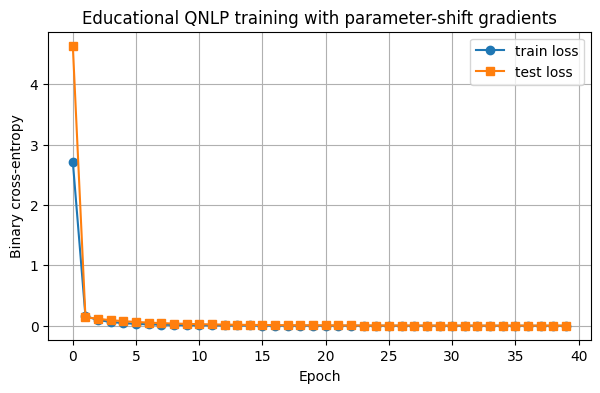

In [9]:
history = []

for epoch in range(40):
    train_loss_before = dataset_loss(train_records, noun_params, verb_params)
    train_acc = dataset_accuracy(train_records, noun_params, verb_params)
    test_loss = dataset_loss(test_records, noun_params, verb_params)
    test_acc = dataset_accuracy(test_records, noun_params, verb_params)

    history.append((epoch, train_loss_before, train_acc, test_loss, test_acc))

    train_step_parameter_shift(train_records, noun_params, verb_params, lr=1.2)

    if epoch % 5 == 0 or epoch == 39:
        print(
            f"epoch={epoch:02d} "
            f"train_loss={train_loss_before:.4f} train_acc={train_acc:.2f} "
            f"test_loss={test_loss:.4f} test_acc={test_acc:.2f}"
        )

epochs = [h[0] for h in history]
train_losses = [h[1] for h in history]
test_losses = [h[3] for h in history]

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, marker="o", label="train loss")
plt.plot(epochs, test_losses, marker="s", label="test loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Educational QNLP training with parameter-shift gradients")
plt.grid(True)
plt.legend()
plt.show()

## 9. Inspect predictions

Interpret the results carefully:

- Training accuracy measures fit to the teaching corpus.
- Test accuracy measures held-out examples from the same small manually designed distribution.
- This is not evidence of broad language understanding.

In [10]:
def print_predictions(data, title):
    print()
    print("=" * 80)
    print(title)
    print("=" * 80)
    for row in data:
        p = truth_probability(row, noun_params, verb_params)
        pred = int(p >= 0.5)
        print(f"{row['sentence']:<32} label={row['label']} pred={pred} p={p:.3f}")

print_predictions(train_records, "Training predictions")
print_predictions(test_records, "Held-out test predictions")


Training predictions
authors hide errors              label=0 pred=0 p=0.000
teachers value evidence          label=1 pred=1 p=1.000
scientists explain math          label=1 pred=1 p=1.000
engineers hate nonsense          label=0 pred=0 p=0.000
authors explain clarity          label=1 pred=1 p=1.000
engineers break software         label=0 pred=0 p=0.000
reviewers reject flaws           label=0 pred=0 p=0.000
engineers break systems          label=0 pred=0 p=0.000
authors hide flaws               label=0 pred=0 p=0.000
reviewers value evidence         label=1 pred=1 p=1.000
students enjoy music             label=1 pred=1 p=1.000
authors explain evidence         label=1 pred=1 p=1.000
teachers break systems           label=0 pred=0 p=0.000
teachers reject nonsense         label=0 pred=0 p=0.000
engineers solve bugs             label=1 pred=1 p=0.999
students hate errors             label=0 pred=0 p=0.000

Held-out test predictions
authors enjoy music              label=1 pred=1 p=1.000

## 10. Shot-based simulator inference

This converts one trained statevector prediction into a sampled measurement experiment.

In [11]:
test_row = test_records[0]
qc_measured = build_sentence_circuit(test_row, noun_params, verb_params, measure=True)

compiled = transpile(qc_measured, aer_backend)
result = aer_backend.run(compiled, shots=SHOTS).result()
counts = result.get_counts()

print("Sentence:", test_row["sentence"])
print("Label:", test_row["label"])
print("Counts:", counts)
print("Estimated p(sentence=1):", counts.get("1", 0) / SHOTS)

safe_draw_circuit(qc_measured, title="Measured sentence circuit", use_mpl=False)

Sentence: authors enjoy music
Label: 1
Counts: {'1': 1024}
Estimated p(sentence=1): 1.0

Measured sentence circuit
     ┌────────────────┐                                                     
q_0: ┤ Ry(-0.0011056) ├──■───────────────────■──────────────────────────────
     ├───────────────┬┘  │                   │                              
q_1: ┤ Ry(0.0062713) ├───┼───────────────────┼────■───────────────────■─────
     └───────────────┘ ┌─┴─┐┌─────────────┐┌─┴─┐┌─┴─┐┌─────────────┐┌─┴─┐┌─┐
q_2: ──────────────────┤ X ├┤ Ry(-7.9049) ├┤ X ├┤ X ├┤ Ry(-7.7841) ├┤ X ├┤M├
                       └───┘└─────────────┘└───┘└───┘└─────────────┘└───┘└╥┘
c: 1/═════════════════════════════════════════════════════════════════════╩═
                                                                          0 


## 11. Optional IBM Quantum hardware smoke test

This section submits one tiny trained inference circuit to IBM hardware.

It does **not** train on hardware.  
It is not a benchmark.  
It is only a hardware execution smoke test.

In [12]:
if RUN_ON_REAL_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    def connect_ibm_service_with_hardcoded_token(token):
        last_error = None
        for channel in ["ibm_quantum_platform", "ibm_quantum"]:
            try:
                service = QiskitRuntimeService(channel=channel, token=token)
                print("Connected to IBM Quantum using channel:", channel)
                return service
            except Exception as exc:
                last_error = exc
                print("Could not connect with channel:", channel)
                print("Reason:", repr(exc))
        raise RuntimeError("Could not connect to IBM Quantum with the hardcoded token.") from last_error

    service = connect_ibm_service_with_hardcoded_token(TOKEN)

    candidates = [
        b for b in service.backends(simulator=False, operational=True)
        if getattr(b, "num_qubits", 0) >= 3
    ]

    if not candidates:
        raise RuntimeError("No operational IBM hardware backend with at least 3 qubits was found.")

    ibm_backend = sorted(candidates, key=lambda b: b.status().pending_jobs)[0]
    print("Selected IBM backend:", ibm_backend.name)
    print("Pending jobs:", ibm_backend.status().pending_jobs)

    qc_hw = build_sentence_circuit(test_row, noun_params, verb_params, measure=True)

    pm = generate_preset_pass_manager(
        backend=ibm_backend,
        optimization_level=1
    )
    isa_qc = pm.run(qc_hw)

    print("Transpiled depth:", isa_qc.depth())
    print("Operations:", isa_qc.count_ops())
    safe_draw_circuit(isa_qc, title="Transpiled IBM hardware circuit", use_mpl=False)

    sampler = Sampler(mode=ibm_backend)
    job = sampler.run([isa_qc], shots=SHOTS)

    print("Job ID:", job.job_id())
    print("Waiting for hardware result. Queue time may vary.")

    hw_result = job.result()
    print("Raw hardware result:")
    print(hw_result)

    def extract_sampler_counts(result):
        try:
            return result[0].data.c.get_counts()
        except Exception:
            pass
        try:
            return result[0].data.meas.get_counts()
        except Exception:
            pass
        raise RuntimeError(f"Could not extract counts from result type: {type(result)}")

    hw_counts = extract_sampler_counts(hw_result)
    print("Hardware counts:", hw_counts)
    print("Estimated hardware p(sentence=1):", hw_counts.get("1", 0) / SHOTS)

else:
    print("RUN_ON_REAL_HARDWARE is False. Simulator-only mode is active.")
    print("To use IBM hardware, set RUN_ON_REAL_HARDWARE = True in the runtime-switch cell.")

qiskit_runtime_service._discover_account:WARNING:2026-06-01 14:14:11,945: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-01 14:14:16,002: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Vikrams_instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-01 14:14:16,003: Loading instance: Vikrams_instance, plan: open


Connected to IBM Quantum using channel: ibm_quantum_platform
Selected IBM backend: ibm_marrakesh
Pending jobs: 0
Transpiled depth: 20
Operations: OrderedDict({'rz': 12, 'sx': 10, 'cz': 4, 'measure': 1})

Transpiled IBM hardware circuit
global phase: π/2
           ┌────────┐    ┌────┐    ┌────────────┐  ┌────┐                     »
q_1 -> 12 ─┤ Rz(-π) ├────┤ √X ├────┤ Rz(3.1353) ├──┤ √X ├─────────────────────»
          ┌┴────────┤    ├────┤    └┬─────────┬─┘  └────┘     ┌────────┐┌────┐»
q_2 -> 13 ┤ Rz(π/2) ├────┤ √X ├─────┤ Rz(π/2) ├─────────────■─┤ Rz(-π) ├┤ √X ├»
          └──┬────┬─┘┌───┴────┴───┐ └──┬────┬─┘  ┌────────┐ │ └────────┘└────┘»
q_0 -> 14 ───┤ √X ├──┤ Rz(3.1405) ├────┤ √X ├────┤ Rz(-π) ├─■─────────────────»
             └────┘  └────────────┘    └────┘    └────────┘                   »
     c: 1/════════════════════════════════════════════════════════════════════»
                                                                              »
«                         

## 12. Honest claims

This notebook can claim:

- It demonstrates an offline-safe educational QNLP-style model for short manually annotated SVO sentences.
- Grammar roles control the quantum circuit topology.
- Nouns are represented by trainable state-preparation parameters.
- Transitive verbs are represented by trainable entangling operations.
- Training uses the parameter-shift rule.
- Evaluation includes a held-out test split.
- One small trained inference circuit can optionally be sampled on IBM hardware.
